In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import norm
PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION="python"
from causal_nets import causal_net_estimate
import tensorflow as tf

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 10)]         0           []                               
                                                                                                  
 dense (Dense)                  (None, 60)           660         ['input_1[0][0]']                
                                                                                                  
 dropout (Dropout)              (None, 60)           0           ['dense[0][0]']                  
                                                                                                  
 dense_1 (Dense)                (None, 30)           1830        ['dropout[0][0]']                
                                                                                              

C:\Users\klaus\AppData\Local\Temp\ipykernel_6624\3031916272.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bins = np.linspace(min(float(min(tau_pred)), float(min(tau_real))),
C:\Users\klaus\AppData\Local\Temp\ipykernel_6624\3031916272.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max(float(max(tau_pred)), float(max(tau_real))), 15)
C:\Users\klaus\AppData\Local\Temp\ipykernel_6624\3031916272.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bins = np

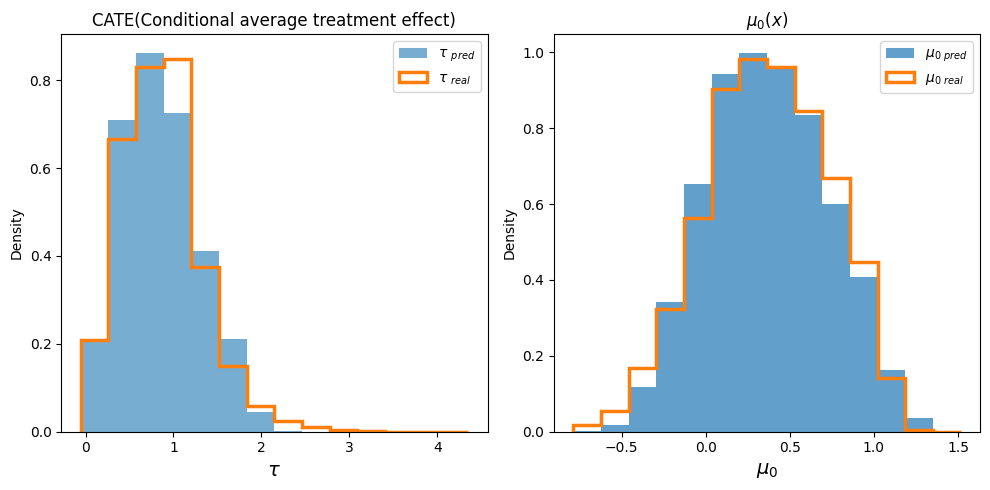

In [4]:
# Setting the seeds
np.random.seed(3)

# Generating the fake data
N = 10000
X = np.random.uniform(low=0, high=1, size=[N, 10])
mu0_real = 1.5 + 0.012*X[:, 3] - 0.75*X[:, 5]*X[:, 7] - 0.9*X[:, 4] - np.mean(X, axis=1)
tau_real = X[:, 2] + 0.04*X[:, 9] - 0.35*np.log(X[:, 3])
prob_of_T = 0.5
T = np.random.binomial(size=N, n=1, p=prob_of_T)
normal_errors = np.random.normal(size=[N, ], loc=0.0, scale=1.0)
Y = mu0_real + tau_real*T + normal_errors

# Creating training and validation dataset
X_train, X_valid, T_train, T_valid, Y_train, Y_valid = train_test_split(
    X, T, Y, test_size=0.2, random_state=42)

# Getting causal estimates
tau_pred, mu0_pred, prob_t_pred, psi_0, psi_1, history, history_ps = causal_net_estimate(
    training_data=[X_train, T_train, Y_train],
    validation_data=[X_valid, T_valid, Y_valid],
    test_data=[X, T, Y],
    hidden_layer_sizes=[60, 30],
    dropout_rates=None,
    batch_size=None,
    alpha=0.,
    r_par=0.,
    optimizer='Adam',
    learning_rate=0.0009,
    max_epochs_without_change=30,
    max_nepochs=10000,
    seed=None,
    estimate_ps=False,
    verbose=True)

# Plotting estimated coefficient vs true coefficients
plt.figure(figsize=(10, 5))
plt.clf()

plt.subplot(1, 2, 1)
bins = np.linspace(min(float(min(tau_pred)), float(min(tau_real))),
                   max(float(max(tau_pred)), float(max(tau_real))), 15)
plt.hist(tau_pred, alpha=0.6, label=r'$\tau~_{pred}$',
         density=True, bins=bins)
plt.hist(tau_real, label=r'$\tau~_{ real}$', histtype=u'step',
         density=True, linewidth=2.5, bins=bins)
plt.legend(loc='upper right')
plt.title('CATE(Conditional average treatment effect)')
plt.xlabel(r'$\tau$', fontsize=14)
plt.ylabel('Density')

plt.subplot(1, 2, 2)
bins = np.linspace(min(float(min(mu0_pred)), float(min(mu0_real))),
                   max(float(max(mu0_pred)), float(max(mu0_real))), 15)
plt.hist(mu0_pred, alpha=0.7, label=r'$\mu_{0~pred}$',
         density=True, bins=bins)
plt.hist(mu0_real, label=r'$\mu_{0~real}$', histtype=u'step',
         density=True, linewidth=2.5, bins=bins)
plt.legend(loc='upper right')
plt.title(r'$\mu_0(x)$')
plt.xlabel(r'$\mu_0$', fontsize=14)
plt.ylabel('Density')

plt.tight_layout()
plt.show()

# Calculate the average treatment effect
ate = np.mean(psi_1-psi_0)

# Calculate the 95% confidence interval for average treatment effect
CI_lowerbound = ate - norm.ppf(0.975)*np.std(psi_1-psi_0)/np.sqrt(len(psi_0))
CI_upperbound = ate + norm.ppf(0.975)*np.std(psi_1-psi_0)/np.sqrt(len(psi_0))